In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib

In [2]:
x_train_pre = joblib.load('x_train_presplit_smote.pkl')
y_train_pre = joblib.load('y_train_presplit_smote.pkl')
x_test_pre  = joblib.load('x_test_presplit_smote.pkl')
y_test_pre  = joblib.load('y_test_presplit_smote.pkl')

In [3]:
svm_model_pre = SVC(
    kernel='rbf',
    probability=True,
    random_state=20
)
svm_model_pre.fit(x_train_pre, y_train_pre)

svm_pred_pre = svm_model_pre.predict(x_test_pre)
svm_prob_pre = svm_model_pre.predict_proba(x_test_pre)[:, 1]
print(svm_prob_pre)

[9.88681113e-01 8.38358899e-01 5.69767707e-01 2.19540997e-01
 9.99997514e-01 1.89152796e-01 6.79803279e-02 9.70884958e-01
 5.80748699e-01 9.63870436e-01 8.74076755e-02 6.56880780e-01
 9.86199720e-01 9.19107856e-01 2.26040347e-01 9.91138784e-01
 9.97193800e-01 6.48387502e-03 9.11547814e-01 5.36022066e-01
 3.80446007e-02 9.70453157e-03 1.48349940e-02 2.58208474e-03
 3.03707204e-02 1.00481900e-01 8.80869852e-01 9.62311272e-01
 9.72646132e-01 7.19437678e-01 2.18681739e-02 6.15640701e-02
 3.54726126e-02 4.34694580e-01 9.27458740e-01 9.75247071e-01
 9.11707289e-02 4.49746838e-01 2.30809737e-02 7.06346639e-01
 3.53018651e-01 1.70217864e-01 1.37955658e-02 7.37055124e-01
 2.75840510e-02 9.75107041e-01 9.63400897e-01 2.85181625e-02
 9.00427494e-01 4.59695078e-01 8.15073173e-02 9.54313790e-01
 9.31758390e-01 9.95720414e-01 9.99998079e-01 1.68329611e-01
 8.86289790e-01 9.08795288e-01 3.19141399e-01 3.70113326e-01
 1.25804244e-01 9.92307650e-01 1.92795691e-02 3.47165123e-01
 2.74844112e-03 7.901091

In [4]:
svm_accuracy_pre = accuracy_score(y_test_pre, svm_pred_pre)
print("SVM Accuracy (Pre-split SMOTE):", round(svm_accuracy_pre, 4))

SVM Accuracy (Pre-split SMOTE): 0.8999


In [5]:

print("Classification Report\n")
print(classification_report(y_test_pre, svm_pred_pre))

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       339
           1       0.90      0.90      0.90       340

    accuracy                           0.90       679
   macro avg       0.90      0.90      0.90       679
weighted avg       0.90      0.90      0.90       679



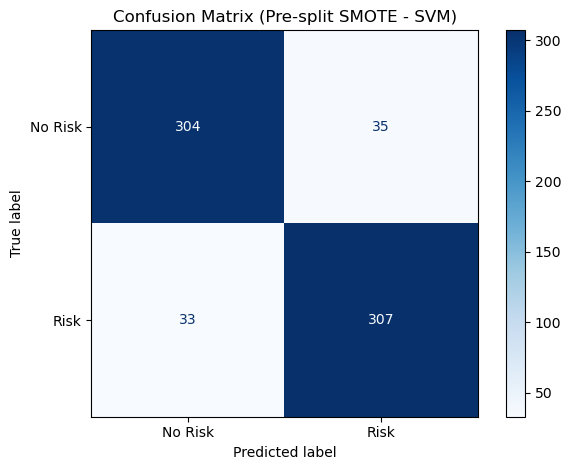

In [6]:
ConfusionMatrixDisplay.from_predictions(
    y_test_pre, svm_pred_pre, display_labels=['No Risk', 'Risk'], cmap='Blues'
)
plt.title("Confusion Matrix (Pre-split SMOTE - SVM)")
plt.tight_layout()
plt.show()

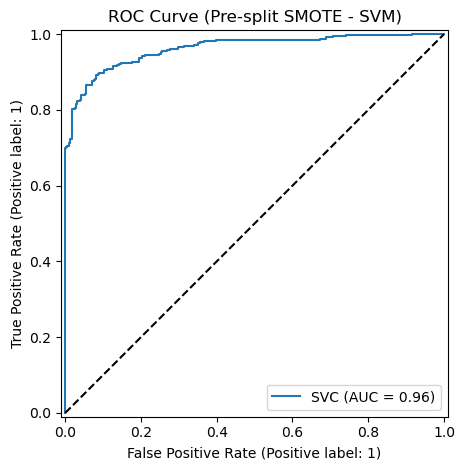

ROC-AUC Score: 0.9622


In [7]:
RocCurveDisplay.from_estimator(svm_model_pre, x_test_pre, y_test_pre)
plt.title('ROC Curve (Pre-split SMOTE - SVM)')
plt.plot([0, 1], [0, 1], 'k--')
plt.tight_layout()
plt.show()

print('ROC-AUC Score:', roc_auc_score(y_test_pre, svm_prob_pre).round(4))

In [8]:
precision_pre = precision_score(y_test_pre, svm_pred_pre)
recall_pre    = recall_score(y_test_pre, svm_pred_pre)
f1_pre        = f1_score(y_test_pre, svm_pred_pre)

print("Precision:", round(precision_pre, 4))
print("Recall   :", round(recall_pre, 4))
print("F1 Score :", round(f1_pre, 4))

Precision: 0.8977
Recall   : 0.9029
F1 Score : 0.9003


In [9]:
train_pred_pre = svm_model_pre.predict(x_train_pre)
print("Train Accuracy:", round(accuracy_score(y_train_pre, train_pred_pre), 4))
print("Test Accuracy :", round(svm_accuracy_pre, 4))

Train Accuracy: 0.9543
Test Accuracy : 0.8999


In [10]:
param_grid = {
    'C':      [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto']
}

grid_search_pre = GridSearchCV(
    SVC(probability=True, random_state=20),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search_pre.fit(x_train_pre, y_train_pre)


GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=20), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['rbf', 'linear']},
             scoring='roc_auc')

In [11]:
print("Best Params:", grid_search_pre.best_params_)
best_model_pre = grid_search_pre.best_estimator_

Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [12]:

best_pred_pre = best_model_pre.predict(x_test_pre)
best_prob_pre = best_model_pre.predict_proba(x_test_pre)[:, 1]
print("Best Model Accuracy:", round(accuracy_score(y_test_pre, best_pred_pre), 4))
print("Best Model ROC-AUC :", roc_auc_score(y_test_pre, best_prob_pre).round(4))


Best Model Accuracy: 0.8954
Best Model ROC-AUC : 0.9725


In [13]:
cv_scores_pre = cross_val_score(svm_model_pre, x_train_pre, y_train_pre, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores_pre.round(4))
print("Mean:", cv_scores_pre.mean().round(4), "| Std dev:", cv_scores_pre.std().round(4))

CV ROC-AUC Scores: [0.9482 0.9625 0.9434 0.9664 0.9558]
Mean: 0.9553 | Std dev: 0.0086


In [14]:
joblib.dump(svm_model_pre, 'svm_model_presplit_smote.pkl')
print("Model saved.")

Model saved.
